In [26]:
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from generative.losses.adversarial_loss import PatchAdversarialLoss
from generative.losses.perceptual import PerceptualLoss
from generative.networks import nets
from monai import transforms
import SimpleITK as sitk
from torch.nn.functional import one_hot

device = torch.device("cuda")

In [27]:
class GaussianNoise(nn.Module):    
    def __init__(self, mean=0.0, std=0.05):
        super(GaussianNoise, self).__init__()
        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)
    def forward(self, x):
        if self.training:
            return x + torch.normal(mean=self.mean, std=self.std, size=x.size(), device=x.device)
        return x
    
class RandCoarseShuffle(nn.Module):    
    def __init__(self, prob=0.75, holes=16, spatial_size=32):
        super(RandCoarseShuffle, self).__init__()
        self.t = transforms.RandCoarseShuffle(prob=prob, holes=holes, spatial_size=spatial_size)
    def forward(self, x):
        if self.training:
            return self.t(x)
        return x

class SaltAndPepper(nn.Module):    
    def __init__(self, prob=0.05):
        super(SaltAndPepper, self).__init__()
        self.prob = prob
    def __call__(self, x):
        noise_tensor = torch.rand(x.shape)
        salt = torch.max(x)
        pepper = torch.min(x)
        x[noise_tensor < self.prob/2] = salt
        x[noise_tensor > 1-self.prob/2] = pepper
        return x
    
transform = transforms.Compose([
    # transforms.EnsureChannelFirst(channel_dim="1"),  # Ensures a single channel if input has none
    transforms.ToTensor()
])

In [28]:
class AutoEncoderKLPaired(pl.LightningModule):
    def __init__(self, **kwargs):
        super().__init__()
        self.save_hyperparameters()

        latent_channels = 3
        if hasattr(self.hparams, "latent_channels"):
            latent_channels = self.hparams.latent_channels

        self.autoencoderkl = nets.AutoencoderKL(
            spatial_dims=2,
            in_channels=1,
            out_channels=1,
            num_channels=(64, 128, 256),
            latent_channels=latent_channels,
            num_res_blocks=2,
            attention_levels=(False, False, True, True),
            with_encoder_nonlocal_attn=False,
            with_decoder_nonlocal_attn=False,
        )
        self.perceptual_loss = PerceptualLoss(spatial_dims=2, network_type="alex")

        self.automatic_optimization = False

        self.discriminator = nets.PatchDiscriminator(spatial_dims=2, num_layers_d=3, num_channels=64, in_channels=1, out_channels=1)        

        self.adversarial_loss = PatchAdversarialLoss(criterion="least_squares")        

        self.noise_transform = torch.nn.Sequential(
            GaussianNoise(0.0, 0.05),
            RandCoarseShuffle(),
            SaltAndPepper()     
        )
        
    def configure_optimizers(self):
        optimizer_g = optim.AdamW(self.autoencoderkl.parameters(),
                                lr=1e-4,
                                weight_decay=0.01)
        optimizer_d = optim.AdamW(self.discriminator.parameters(),
                                lr=1e-4,
                                weight_decay=0.01)
        return [optimizer_g, optimizer_d]

    def training_step(self, train_batch, batch_idx):
        x = train_batch[0]
        y = train_batch[1]

        optimizer_g, optimizer_d = self.optimizers()
        
        optimizer_g.zero_grad()

        reconstruction, z_mu, z_sigma = self.autoencoderkl(x)

        recons_loss = F.l1_loss(reconstruction.float(), y.float())
        p_loss = self.perceptual_loss(reconstruction.float(), y.float())
        kl_loss = 0.5 * torch.sum(z_mu.pow(2) + z_sigma.pow(2) - torch.log(z_sigma.pow(2)) - 1, dim=[1, 2, 3])
        kl_loss = torch.sum(kl_loss) / kl_loss.shape[0]
        loss_g = recons_loss + (1e-6 * kl_loss) + (0.001 * p_loss)

        if self.trainer.current_epoch >= 0:
            logits_fake = self.discriminator(reconstruction.contiguous().float())[-1]
            generator_loss = self.adversarial_loss(logits_fake, target_is_real=True, for_discriminator=False)
            loss_g += 0.01 * generator_loss

        loss_g.backward()
        optimizer_g.step()
        
        loss_d = 0
        if self.trainer.current_epoch >= 0:
            
            optimizer_d.zero_grad()

            logits_fake = self.discriminator(reconstruction.contiguous().detach())[-1]
            loss_d_fake = self.adversarial_loss(logits_fake, target_is_real=False, for_discriminator=True)
            logits_real = self.discriminator(y.contiguous().detach())[-1]
            loss_d_real = self.adversarial_loss(logits_real, target_is_real=True, for_discriminator=True)
            discriminator_loss = (loss_d_fake + loss_d_real) * 0.5

            loss_d = 0.01 * discriminator_loss

            loss_d.backward()
            optimizer_d.step()

        self.log("train_loss_g", loss_g)
        self.log("train_loss_d", loss_d)

        return {"train_loss_g": loss_g, "train_loss_d": loss_d} 

    def validation_step(self, val_batch, batch_idx):
        x = val_batch[0]
        y = val_batch[1]
        # with autocast(enabled=True):
        #     reconstruction, z_mu, z_sigma = self.autoencoderkl(x)
        #     recon_loss = F.l1_loss(x.float(), reconstruction.float())

        reconstruction, z_mu, z_sigma = self.autoencoderkl(x)
        recon_loss = F.l1_loss(y.float(), reconstruction.float())

        self.log("val_loss", recon_loss, sync_dist=True)

    def forward(self, images): 
        images = one_hot(images.long()).permute(0,3,1,2)  
        print(images.shape) 
        return self.autoencoderkl(images)

In [29]:
from torch.nn.functional import one_hot
# Load the trained model
model = AutoEncoderKLPaired()
state_dict = torch.load("/mnt/raid/home/ajarry/data/autoencoder/output_20250416_115138/model.pth")
model.load_state_dict(state_dict=state_dict, strict=False)
model = model.to(device)
model.eval()  # Set to evaluation mode


ValueError: AutoencoderKL expects num_channels being same size of attention_levels

In [30]:
type_frame = "M"
frame = 80
# Load an image (grayscale)
image_path = "/mnt/raid/C1_ML_Analysis/simulated_data_export/placenta_simu/FAM-025-0795-1_label11/" + type_frame + "_label/"+ str(frame) + ".nrrd"
target_path = "/mnt/raid/C1_ML_Analysis/simulated_data_export/placenta_simu/FAM-025-0795-1_label11/" + type_frame +"_guided/" + str(frame) + ".nrrd"
image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
target = sitk.GetArrayFromImage(sitk.ReadImage(target_path))

input_image = transform(image).unsqueeze(0).unsqueeze(0).to(device)

In [31]:
with torch.no_grad():
    # Pass through the autoencoder
    # encoded, _ = model.autoencoderkl.encode(input_image)
    # decoded = model.autoencoderkl.decode(encoded)
    decoded, z_mu, z_sigma = model.autoencoderkl(input_image)



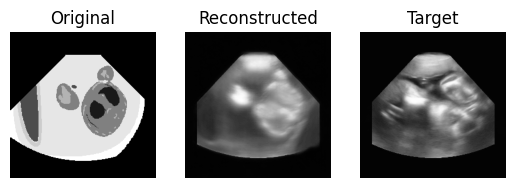

In [32]:
decoded_image = decoded.cpu().numpy().squeeze()
# Plot original and reconstructed images
fig, ax = plt.subplots(1, 3)
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(decoded_image, cmap="gray")
ax[1].set_title("Reconstructed")
ax[1].axis("off")
ax[2].imshow(target, cmap="gray")
ax[2].set_title("Target")
ax[2].axis("off")
plt.show()

In [33]:

# x = torch.randint(low=0, high=11, size=(1, 1, 256, 256)).to(torch.float)

# guided_traced = torch.jit.trace(model.autoencoderkl, (x.cuda(),))
# guided_traced.save("/mnt/raid/home/ajarry/data/autoencoder/ae_one_hot_200e/model_traced.pt")